In [37]:
# Physics background
# ------------------
#  Transport through a graphene quantum dot with a pn-junction
#
# Kwant features highlighted
# --------------------------
#  - Application of all the aspects of tutorials 1-3 to a more complicated
#    lattice, namely graphenefrom math import pi, sqrt, tanh
import kwant
import numpy as np
from matplotlib import pyplot
import scipy.sparse.linalg as sla
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

In [38]:
sin_30, cos_30 = (1 / 2, np.sqrt(3) / 2)
r = 10
w = 2.0
pot = 0.1

In [39]:
graphene = kwant.lattice.general([(1, 0), (sin_30, cos_30)], [(0, 0), (0, 1 / np.sqrt(3))], norbs=1)
a, b = graphene.sublattices

In [40]:
def circle(pos):
    x, y = pos
    return x ** 2 + y ** 2 < r ** 2

def potential(site):
    (x, y) = site.pos
    d = y * cos_30 + x * sin_30
    return pot * np.tanh(d / w)

In [41]:
syst = kwant.Builder()
syst[graphene.shape(circle, (0, 0))] = potential
hoppings = (((0, 0), a, b), ((0, 1), a, b), ((-1, 1), a, b))
syst[[kwant.builder.HoppingKind(*hopping) for hopping in hoppings]] = -1

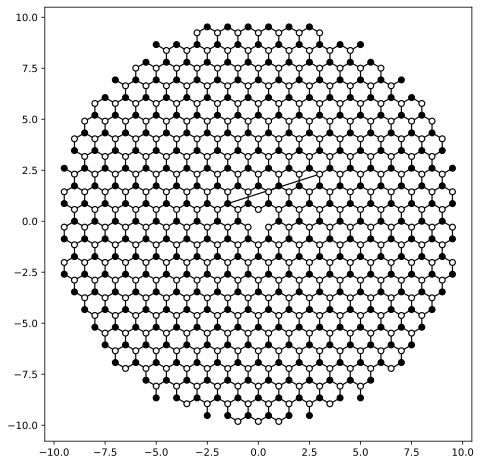

[ 3.07869311 -3.06233144]


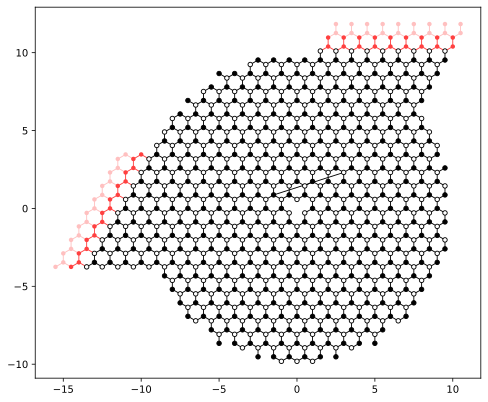

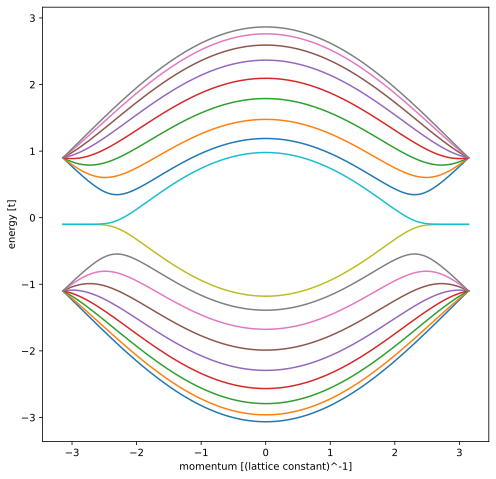

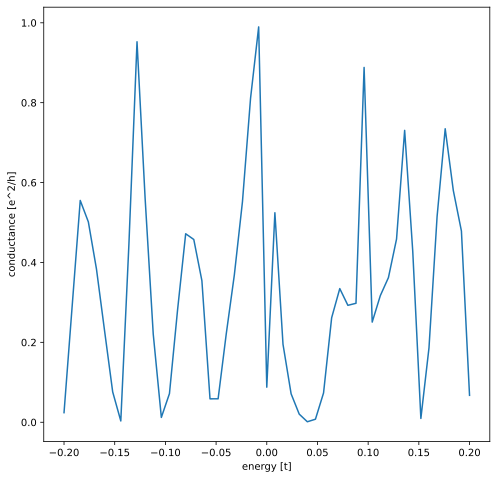

In [42]:
# Modify the scattering region
del syst[a(0, 0)]
syst[a(-2, 1), b(2, 2)] = -1

# left lead
sym0 = kwant.TranslationalSymmetry(graphene.vec((-1, 0)))
def lead0_shape(pos):
    x, y = pos
    return (-0.4 * r < y < 0.4 * r)

lead0 = kwant.Builder(sym0)
lead0[graphene.shape(lead0_shape, (0, 0))] = -pot
lead0[[kwant.builder.HoppingKind(*hopping) for hopping in hoppings]] = -1

# The second lead, going to the top right
sym1 = kwant.TranslationalSymmetry(graphene.vec((0, 1)))

def lead1_shape(pos):
    v = pos[1] * sin_30 - pos[0] * cos_30
    return (-0.4 * r < v < 0.4 * r)

lead1 = kwant.Builder(sym1)
lead1[graphene.shape(lead1_shape, (0, 0))] = pot
lead1[[kwant.builder.HoppingKind(*hopping) for hopping in hoppings]] = -1

def compute_evs(syst):
    # Compute some eigenvalues of the closed system
    sparse_mat = syst.hamiltonian_submatrix(sparse=True)

    evs = sla.eigs(sparse_mat, 2)[0]
    print(evs.real)

def plot_conductance(syst, energies):
    # Compute transmission as a function of energy
    data = []
    for energy in energies:
        smatrix = kwant.smatrix(syst, energy)
        data.append(smatrix.transmission(0, 1))

    pyplot.figure()
    pyplot.plot(energies, data)
    pyplot.xlabel("energy [t]")
    pyplot.ylabel("conductance [e^2/h]")
    pyplot.show()


def plot_bandstructure(flead, momenta):
    bands = kwant.physics.Bands(flead)
    energies = [bands(k) for k in momenta]

    pyplot.figure()
    pyplot.plot(momenta, energies)
    pyplot.xlabel("momentum [(lattice constant)^-1]")
    pyplot.ylabel("energy [t]")
    pyplot.show()

# To highlight the two sublattices of graphene, we plot one with
# a filled, and the other one with an open circle:
def family_colors(site):
    return 0 if site.family == a else 1

# Plot the closed system without leads.
kwant.plot(syst, site_color=family_colors, site_lw=0.1, colorbar=False);
compute_evs(syst.finalized())

# Attach the leads to the system.
for lead in [lead0, lead1]:
    syst.attach_lead(lead)

# Then, plot the system with leads.
kwant.plot(syst, site_color=family_colors, site_lw=0.1,
           lead_site_lw=0, colorbar=False);

syst = syst.finalized()

# Compute the band structure of lead 0.
momenta = [-np.pi + 0.02 * np.pi * i for i in range(101)]
plot_bandstructure(syst.leads[0], momenta)

# Plot conductance.
energies = [-2 * pot + 4. / 50. * pot * i for i in range(51)]
plot_conductance(syst, energies)